# 02 subtype discovery review

이 노트북은 **base run 또는 임시 run 결과를 빠르게 확인**하고, 작은 config override로 재실행해보는 용도다.

In [1]:
from pathlib import Path
import sys, subprocess

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.append(str(PROJECT_ROOT / "src"))

from subtype.io_utils import read_yaml, write_yaml, load_run_outputs


## 1. base config / base run 경로 설정

In [2]:
BASE_CONFIG = PROJECT_ROOT / "configs" / "subtype_base.yaml"
cfg = read_yaml(BASE_CONFIG)
BASE_RUN_DIR = PROJECT_ROOT / cfg["paths"]["outdir"]
cfg["paths"]["outdir"], BASE_RUN_DIR


('data/20260309_pilot/results/subtype_discovery/base_run',
 PosixPath('/data/podo/Projects/project_jhl/20260215_nsclc/data/20260309_pilot/results/subtype_discovery/base_run'))

## 2. base run 결과 읽기

In [3]:
run = load_run_outputs(BASE_RUN_DIR)

print("metrics")
display(pd.DataFrame([run["metrics"]]) if run["metrics"] is not None else pd.DataFrame())

print("\ncohort_info")
display(pd.DataFrame([run["cohort_info"]]) if run["cohort_info"] is not None else pd.DataFrame())

print("\nselected_features")
display(pd.DataFrame({"selected_feature": run["selected_features"]["selected_features"]})
        if run["selected_features"] is not None else pd.DataFrame())


metrics


,n_patients,n_features,best_k,best_silhouette,selected_feature_names,clustering_notes
0,85,42,6,0.459259,"[prop_B, prop_CD14 Mono, prop_CD16 Mono, prop_...",[]



cohort_info


,selected_patients_file,selected_patients_n,healthy_sampled_ids,n_cells_total,n_patients_total,n_disease_patients,n_healthy_patients,required_celltypes
0,data/20260309_pilot/results/20260313_patients_...,78,"[KR_SGI_H005, KR_SGI_H012, KR_SGI_H035, KR_SGI...",273174,85,78,7,"[B, CD14 Mono, CD16 Mono, NK, T/NK, effector C..."



selected_features


,selected_feature
0,prop_B
1,prop_CD14 Mono
2,prop_CD16 Mono
3,prop_NK
4,prop_T/NK
5,prop_effector CD8+T
6,prop_naive/TCM CD4+T
7,naive/TCM CD4+T_PC1
8,naive/TCM CD4+T_PC2
9,naive/TCM CD4+T_PC3


## 3. cluster / source / batch 분포 확인

In [4]:
pf = run["patient_features_batch_adjusted"]
clusters = run["patient_clusters"]

if pf is not None and clusters is not None:
    merged = pf.merge(clusters, on="analysis_id", how="left")
    display(pd.crosstab(merged["source"], merged["patient_cluster"]))
    if "batch" in merged.columns:
        display(pd.crosstab(merged["batch"], merged["patient_cluster"]))


patient_cluster,1,2,3,4,5,6
source,,,,,,
AIDA,2,1,1,1,1,1
Lee_p1,1,0,0,77,0,0


patient_cluster,1,2,3,4,5,6
batch,,,,,,
1-IO_base,0,0,0,4,0,0
10-IO_base,0,0,0,3,0,0
11-IO_base,0,0,0,4,0,0
12-IO_base,0,0,0,4,0,0
13-IO_base,0,0,0,4,0,0
2-IO_base,0,0,0,4,0,0
3-IO_base,0,0,0,3,0,0
4-IO_base,0,0,0,4,0,0
5-IO_base,0,0,0,4,0,0


## 4. PCA / UMAP quick plot

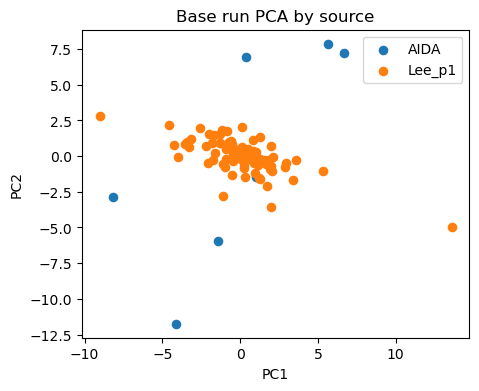

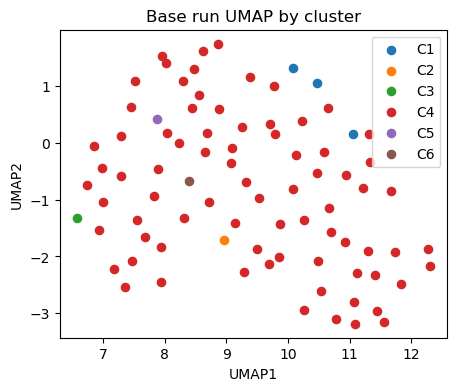

In [5]:
pca_df = run["patient_pca"]
umap_df = run["patient_umap"]
clusters = run["patient_clusters"]
pf = run["patient_features_batch_adjusted"]

if pca_df is not None and pf is not None:
    pca_plot = pca_df.merge(pf[["analysis_id", "source"]], on="analysis_id", how="left")
    plt.figure(figsize=(5,4))
    for s in sorted(pca_plot["source"].dropna().unique()):
        sub = pca_plot[pca_plot["source"] == s]
        plt.scatter(sub["PC1"], sub["PC2"], s=35, label=s)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Base run PCA by source")
    plt.legend()
    plt.show()

if umap_df is not None and clusters is not None:
    umap_plot = umap_df.merge(clusters, on="analysis_id", how="left")
    plt.figure(figsize=(5,4))
    for s in sorted(umap_plot["patient_cluster"].dropna().unique()):
        sub = umap_plot[umap_plot["patient_cluster"] == s]
        plt.scatter(sub["UMAP1"], sub["UMAP2"], s=35, label=f"C{s}")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title("Base run UMAP by cluster")
    plt.legend()
    plt.show()


## 5. feature screening tables 확인

In [6]:
display(run["prop_related_df"].head(20) if run["prop_related_df"] is not None else pd.DataFrame())
display(run["resid_signal_df"].head(20) if run["resid_signal_df"] is not None else pd.DataFrame())
display(run["pca_nmf_redundancy"].head(20) if run["pca_nmf_redundancy"] is not None else pd.DataFrame())


,prop_feature,feature,celltype,feature_type,correlation,abs_correlation
0,prop_CD14 Mono,CD14 Mono_NMF1,CD14 Mono,nmf,0.409341,0.409341
1,prop_B,B_PC3,B,pca,-0.363637,0.363637
2,prop_CD16 Mono,CD16 Mono_PC3,CD16 Mono,pca,0.353889,0.353889
3,prop_B,B_PC2,B,pca,0.302770,0.302770
4,prop_effector CD8+T,effector CD8+T_PC2,effector CD8+T,pca,-0.299504,0.299504
5,prop_naive/TCM CD4+T,naive/TCM CD4+T_PC1,naive/TCM CD4+T,pca,-0.299056,0.299056
6,prop_NK,NK_PC4,NK,pca,0.295592,0.295592
7,prop_effector CD8+T,effector CD8+T_PC4,effector CD8+T,pca,0.268944,0.268944
8,prop_naive/TCM CD4+T,naive/TCM CD4+T_PC5,naive/TCM CD4+T,pca,0.261871,0.261871
9,prop_naive/TCM CD4+T,naive/TCM CD4+T_NMF1,naive/TCM CD4+T,nmf,-0.258271,0.258271


,prop_feature,feature,celltype,feature_type,r_squared,raw_sd,residual_sd,residual_ratio
0,prop_CD14 Mono,CD14 Mono_NMF1,CD14 Mono,nmf,0.167560,19.497613,17.789261,0.912381
1,prop_B,B_PC3,B,pca,0.132232,28.889576,26.911819,0.931541
2,prop_CD16 Mono,CD16 Mono_PC3,CD16 Mono,pca,0.125238,29.525079,27.614433,0.935287
3,prop_B,B_PC2,B,pca,0.091670,34.483632,32.865096,0.953064
4,prop_effector CD8+T,effector CD8+T_PC2,effector CD8+T,pca,0.089703,38.084399,36.336136,0.954095
5,prop_naive/TCM CD4+T,naive/TCM CD4+T_PC1,naive/TCM CD4+T,pca,0.089435,90.579236,86.433920,0.954235
6,prop_NK,NK_PC4,NK,pca,0.087375,27.858007,26.613147,0.955314
7,prop_effector CD8+T,effector CD8+T_PC4,effector CD8+T,pca,0.072331,30.000148,28.894817,0.963156
8,prop_naive/TCM CD4+T,naive/TCM CD4+T_PC5,naive/TCM CD4+T,pca,0.068577,29.035187,28.021939,0.965103
9,prop_naive/TCM CD4+T,naive/TCM CD4+T_NMF1,naive/TCM CD4+T,nmf,0.066704,7.351014,7.101613,0.966072


,celltype,pca_feature,nmf_feature,correlation,abs_correlation
0,NK,NK_PC1,NK_NMF1,0.960828,0.960828
1,NK,NK_PC1,NK_NMF2,-0.952867,0.952867
2,CD14 Mono,CD14 Mono_PC1,CD14 Mono_NMF2,-0.929959,0.929959
3,naive/TCM CD4+T,naive/TCM CD4+T_PC3,naive/TCM CD4+T_NMF2,-0.878406,0.878406
4,effector CD8+T,effector CD8+T_PC1,effector CD8+T_NMF2,0.834239,0.834239
5,effector CD8+T,effector CD8+T_PC3,effector CD8+T_NMF1,0.820844,0.820844
6,NK,NK_PC3,NK_NMF3,0.819985,0.819985
7,naive/TCM CD4+T,naive/TCM CD4+T_PC1,naive/TCM CD4+T_NMF1,0.764055,0.764055
8,CD14 Mono,CD14 Mono_PC2,CD14 Mono_NMF3,-0.615711,0.615711
9,CD14 Mono,CD14 Mono_PC1,CD14 Mono_NMF1,0.465492,0.465492


## 6. 작은 config override로 임시 run 돌리기

In [ ]:
def set_nested(cfg, dotted_key, value):
    parts = dotted_key.split(".")
    cur = cfg
    for p in parts[:-1]:
        if p not in cur or not isinstance(cur[p], dict):
            cur[p] = {}
        cur = cur[p]
    cur[parts[-1]] = value


def run_with_overrides(base_config_path, overrides, run_name="tmp_notebook_run"):
    cfg = read_yaml(base_config_path)
    for k, v in overrides.items():
        set_nested(cfg, k, v)

    tmp_outdir = PROJECT_ROOT / "data" / "20260309_pilot" / "results" / "subtype_discovery" / run_name
    cfg["paths"]["outdir"] = str(tmp_outdir)
    tmp_outdir.mkdir(parents=True, exist_ok=True)

    tmp_cfg = tmp_outdir / "config.yaml"
    write_yaml(cfg, tmp_cfg)

    cmd = ["python", "src/run_subtype_pipeline.py", "--config", str(tmp_cfg)]
    result = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)

    print("returncode:", result.returncode)
    print(result.stdout[-1000:])
    if result.returncode != 0:
        print(result.stderr[-2000:])

    return tmp_outdir


In [ ]:
overrides = {
    "healthy_sampling.n_healthy": 5,
    "pseudobulk.min_cells_per_patient_celltype": 10,
    "nmf_features.rank": 2,
    "patient_clustering.n_pcs_patient": 8,
}

tmp_dir = run_with_overrides(BASE_CONFIG, overrides, run_name="tmp_review_run")
tmp_dir


## 7. 임시 run 결과 비교

In [ ]:
tmp_run = load_run_outputs(tmp_dir)

print("Base metrics")
display(pd.DataFrame([run["metrics"]]) if run["metrics"] is not None else pd.DataFrame())

print("Override metrics")
display(pd.DataFrame([tmp_run["metrics"]]) if tmp_run["metrics"] is not None else pd.DataFrame())


In [ ]:
if tmp_run["patient_umap"] is not None and tmp_run["patient_clusters"] is not None:
    tmp_umap = tmp_run["patient_umap"].merge(tmp_run["patient_clusters"], on="analysis_id", how="left")
    plt.figure(figsize=(5,4))
    for s in sorted(tmp_umap["patient_cluster"].dropna().unique()):
        sub = tmp_umap[tmp_umap["patient_cluster"] == s]
        plt.scatter(sub["UMAP1"], sub["UMAP2"], s=35, label=f"C{s}")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title("Override run UMAP by cluster")
    plt.legend()
    plt.show()


## 8. 자주 바꿔볼 만한 파라미터

- `healthy_sampling.n_healthy`
- `pseudobulk.min_cells_per_patient_celltype`
- `pca_features.npcs_per_celltype`
- `nmf_features.rank`
- `feature_selection.prefer`
- `patient_clustering.n_pcs_patient`